# Darts - Recurrent Neural Networks

In [21]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from darts import TimeSeries
import darts.metrics as metrics
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler, MissingValuesFiller

import torch
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
file = "datas/magnific7_1day.pkl"
series_dict = pd.read_pickle(file)

In [4]:
for key in series_dict:
    print(f"{key}: {type(series_dict[key])}")
    print("=====================================")

APPLE: <class 'pandas.core.frame.DataFrame'>
MICROSOFT: <class 'pandas.core.frame.DataFrame'>
AMAZON: <class 'pandas.core.frame.DataFrame'>
ALPHABET: <class 'pandas.core.frame.DataFrame'>
NVIDIA: <class 'pandas.core.frame.DataFrame'>
META: <class 'pandas.core.frame.DataFrame'>
TESLA: <class 'pandas.core.frame.DataFrame'>


#### Détection des trous dans les dates

In [5]:
for name, df in series_dict.items():
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    #Génère toutes les dates ouvrées entre la première et dernière date
    full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')

    #Compare l'index attendu à l'index réel
    missing_dates = full_index.difference(df.index)

    print(f"{name}: {len(missing_dates)} dates manquantes")
    if len(missing_dates) > 0:
        print("Exemples de dates manquantes :", missing_dates[:5])
        print("=====================================")

APPLE: 143 dates manquantes
Exemples de dates manquantes : DatetimeIndex(['2010-01-18', '2010-02-15', '2010-04-02', '2010-05-31',
               '2010-07-05'],
              dtype='datetime64[ns]', freq=None)
MICROSOFT: 143 dates manquantes
Exemples de dates manquantes : DatetimeIndex(['2010-01-18', '2010-02-15', '2010-04-02', '2010-05-31',
               '2010-07-05'],
              dtype='datetime64[ns]', freq=None)
AMAZON: 143 dates manquantes
Exemples de dates manquantes : DatetimeIndex(['2010-01-18', '2010-02-15', '2010-04-02', '2010-05-31',
               '2010-07-05'],
              dtype='datetime64[ns]', freq=None)
ALPHABET: 143 dates manquantes
Exemples de dates manquantes : DatetimeIndex(['2010-01-18', '2010-02-15', '2010-04-02', '2010-05-31',
               '2010-07-05'],
              dtype='datetime64[ns]', freq=None)
NVIDIA: 143 dates manquantes
Exemples de dates manquantes : DatetimeIndex(['2010-01-18', '2010-02-15', '2010-04-02', '2010-05-31',
               '2010-07-0

### Visualisation des données

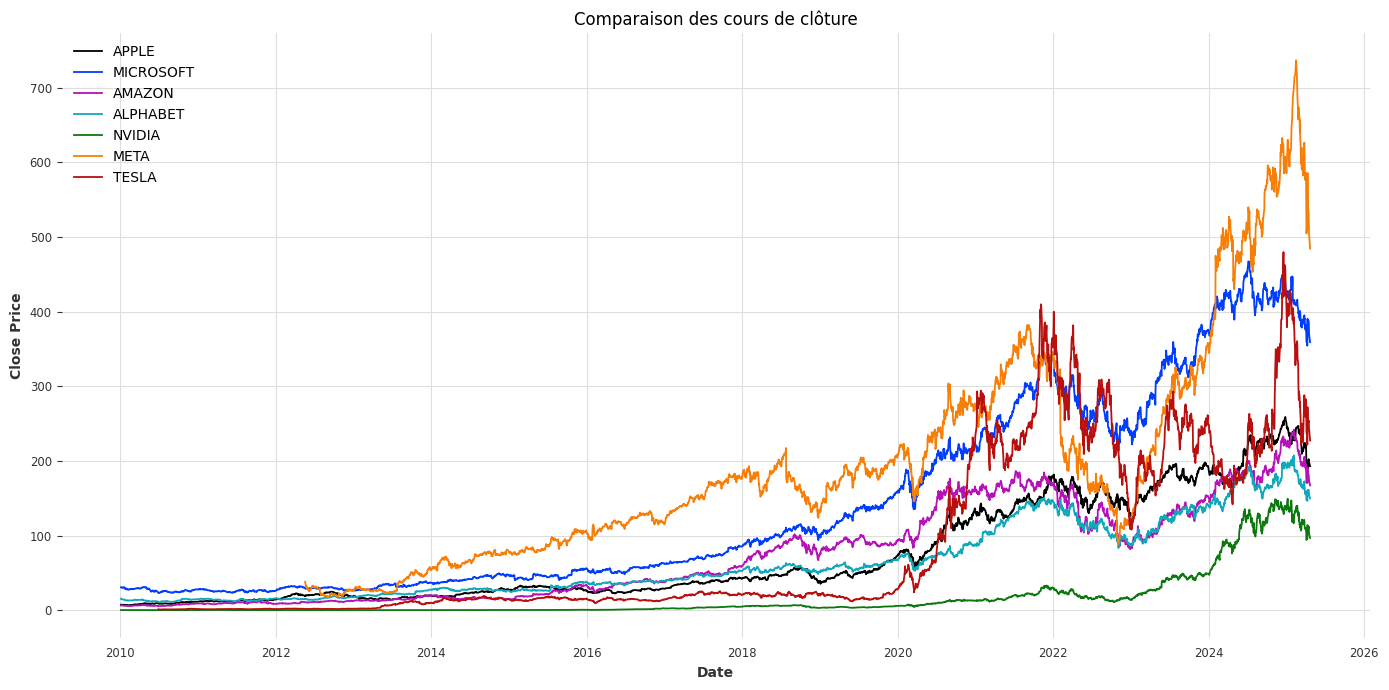

In [6]:
plt.figure(figsize=(14,7))
for name, df in series_dict.items():
    plt.plot(df.index, df['close'], label=name)
plt.title('Comparaison des cours de clôture')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Normalisation des données avant la visualisation

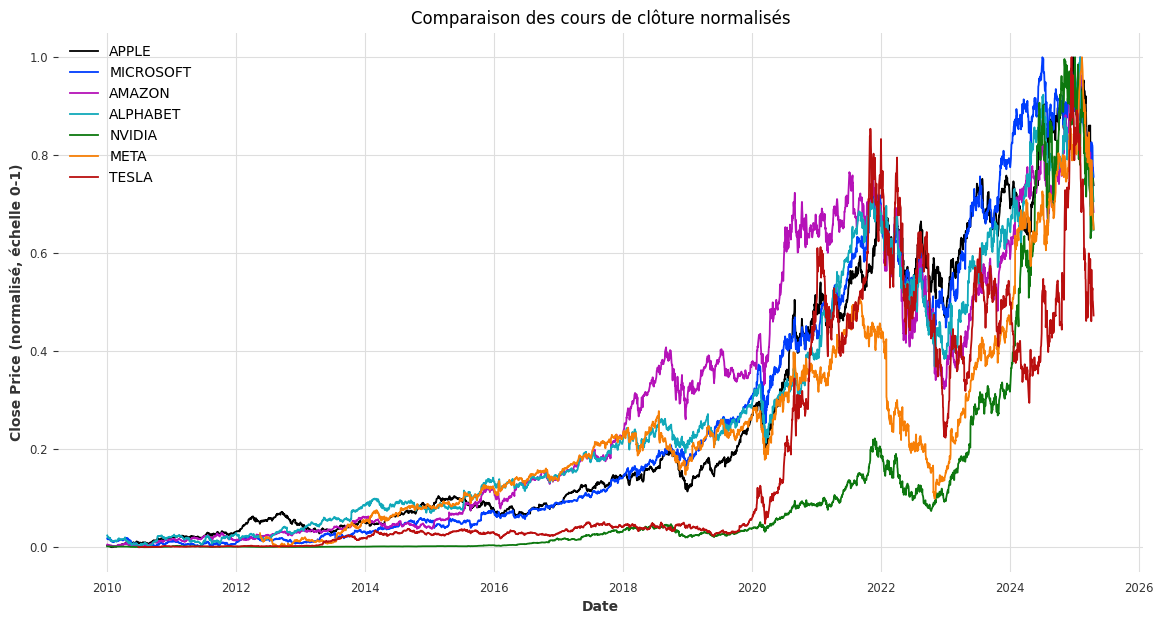

In [7]:
plt.figure(figsize=(14,7))

for name, df in series_dict.items():
    # S'assure que l'index est de type datetime
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    # Normalise les données
    scaler = MinMaxScaler()
    scaled_close = scaler.fit_transform(df[['close']])

    # Tracé
    plt.plot(df.index, scaled_close, label=name)

plt.title('Comparaison des cours de clôture normalisés')
plt.xlabel('Date')
plt.ylabel('Close Price (normalisé, échelle 0-1)')
plt.legend()
plt.grid(True)
plt.show()


### Conversion des 7 dataframes en TimeSeries

-> + Gestion des NaN trouvés dans les données

In [8]:
filler = MissingValuesFiller()

all_series = []
for name, df in series_dict.items():
    df.index = pd.to_datetime(df.index)

    ts = TimeSeries.from_dataframe(df, value_cols='close', fill_missing_dates=True, freq='B')
    ts = filler.transform(ts)
    all_series.append(ts)

### Separation des données

In [9]:
train_series = []
val_series = []

for ts in all_series:
    train, val = ts.split_before(0.8)
    train_series.append(train)
    val_series.append(val)

Vérification des NaN et Inf

In [10]:
for ts in train_series:
    if np.isnan(ts.values()).any():
        print("NaN détecté dans une série")
    if np.isinf(ts.values()).any():
        print("Inf détecté dans une série")

### Normalisation

In [11]:
scalers = []
train_series_scaled = []
val_series_scaled = []

for train, val in zip(train_series, val_series):
    scaler = Scaler()
    train_scaled = scaler.fit_transform(train)
    val_scaled = scaler.transform(val)

    scalers.append(scaler)
    train_series_scaled.append(train_scaled)
    val_series_scaled.append(val_scaled)

Contrôle des NaN ou Inf

In [12]:
for series in train_series_scaled:
    values = series.values()
    if np.any(np.isnan(values)) or np.any(np.isinf(values)):
        print("Série invalide détectée dans train_series_scaled")

### Cuda

In [13]:
if torch.cuda.is_available():
    print(f"CUDA est disponible ! Nombre de GPUs : {torch.cuda.device_count()}")
    gpu_devices = [0]
else:
    print("CUDA n'est pas disponible. Utilisation du CPU.")
    gpu_devices = 0

CUDA est disponible ! Nombre de GPUs : 1


### Implémentation callbacks

EarlyStopping pour éviter le surapprentissage

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.01,
    mode="min",
    verbose=True,
)
pl_trainer_kwargs = {
    "callbacks": [early_stopping],
    "enable_progress_bar": True,
    "accelerator": "gpu",
    "devices": gpu_devices
}

### Modèle RNN

In [15]:
model = RNNModel(
    model='LSTM',   # ou 'GRU', 'RNN'
    input_chunk_length=60, # nombre de jours regardés en arrière
    output_chunk_length=1, # nombre de jours à prédire
    hidden_dim=64, # nombre de neurones dans la couche cachée
    n_rnn_layers=3, # nombre de couches cachées
    dropout=0.2, # taux de dropout pour la régularisation afin de réduire le surapprentissage
    training_length=90, # taille de la séquence d'entraînement
    batch_size=32, # taille du lot (nombre d'échantillons avant de mettre à jour les poids)
    n_epochs=100, # nombre d'époques,
    optimizer_kwargs={'lr': 5e-4}, # paramètres de l'optimiseur = {'lr': learning_rate}
    model_name='lstm_improved', 
    log_tensorboard=True, # pour le suivi de l'entraînement
    random_state=42, # pour la reproductibilité
    force_reset=True, # pour réinitialiser le modèle à chaque fois
    pl_trainer_kwargs=pl_trainer_kwargs, # earlystopping pour éviter le surapprentissage
)

model.fit(train_series_scaled, val_series=val_series_scaled, verbose=True)


ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricColl

Epoch 0: 100%|██████████| 679/679 [00:19<00:00, 34.77it/s, v_num=logs, train_loss=0.00219, val_loss=0.171]

Metric val_loss improved. New best score: 0.171


Epoch 5: 100%|██████████| 679/679 [00:21<00:00, 30.93it/s, v_num=logs, train_loss=0.000192, val_loss=0.140]

Metric val_loss improved by 0.031 >= min_delta = 0.01. New best score: 0.140


Epoch 10: 100%|██████████| 679/679 [00:19<00:00, 35.24it/s, v_num=logs, train_loss=0.000172, val_loss=0.150]   

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.140. Signaling Trainer to stop.


Epoch 10: 100%|██████████| 679/679 [00:19<00:00, 35.24it/s, v_num=logs, train_loss=0.000172, val_loss=0.150]


RNNModel(model=LSTM, hidden_dim=64, n_rnn_layers=3, dropout=0.2, training_length=90, input_chunk_length=60, output_chunk_length=1, batch_size=32, n_epochs=100, optimizer_kwargs={'lr': 0.0005}, model_name=lstm_improved, log_tensorboard=True, random_state=42, force_reset=True, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x7ff6b9f2adb0>], 'enable_progress_bar': True, 'accelerator': 'gpu', 'devices': [0]})

In [16]:
model.save("./models/model_rnn.pickle")
print("Modèle RNN enregistré avec succès !")

Modèle RNN enregistré avec succès !


In [22]:
loaded_model_rnn = RNNModel.load("./models/model_rnn.pickle")
print("Modèle RNN chargé avec succès !")

Modèle RNN chargé avec succès !


### Evaluation du modèle

In [23]:
def evaluate_model_historical_forecasts_rnn(model, 
                                            train_series_scaled, val_series_scaled, scalers_list):
    """
    Évalue un modèle Darts en utilisant historical_forecasts() pour une prédiction pas à pas
    sur les séries de validation.

    Args:
        model: Le modèle Darts entraîné (ici un RNNModel).
        train_series_scaled: Liste des séries d'entraînement mises à l'échelle.
        val_series_scaled: Liste des séries de validation mises à l'échelle.
        scalers_list: Liste des scalers, un pour chaque série.

    Returns:
        pd.DataFrame: Un DataFrame contenant les métriques MAE, RMSE et MAPE.
        list: Liste des prédictions dénormalisées pour chaque série.
    """
    performance = {}
    all_denormalized_predictions = []

    for i in range(len(val_series_scaled)):
        current_train_series = train_series_scaled[i]
        current_val_series = val_series_scaled[i]
        current_scaler = scalers_list[i]

        # Concaténer la série d'entraînement et de validation pour le backtesting
        # historical_forecasts prend la série complète et simule les prédictions.
        full_series_for_backtest = current_train_series.append(current_val_series)

        # Point de départ pour les prédictions historiques (début de la validation)
        start_val_time = current_val_series.start_time()

        try:
            predictions_scaled = model.historical_forecasts(
                series=full_series_for_backtest,
                start=start_val_time,
                forecast_horizon=model.output_chunk_length, # Doit être 1 pour votre RNN
                stride=1, # Prédit un point, puis avance d'un point
                retrain=False, # Ne réentraîne pas le modèle à chaque pas
                last_points_only=True, # Important pour obtenir une série de prédictions "un pas après l'autre"
                verbose=False
            )
            
            # Ajuster les prédictions si elles ne couvrent pas toute la période de validation
            # C'est important car historical_forecasts ne prédit que les points pour lesquels
            # il a un input_chunk_length valide et passé.
            # On s'assure que les prédictions commencent au bon moment et couvrent la bonne durée.
            # Darts devrait normalement aligner les dates. On peut juste prendre l'intersection.
            
            # Dénormalisation
            pred_denormalized = current_scaler.inverse_transform(predictions_scaled)
            actual_denormalized = current_scaler.inverse_transform(current_val_series)

            # Alignement pour le calcul des métriques
            pred_aligned = pred_denormalized.slice_intersect(actual_denormalized)
            actual_aligned = actual_denormalized.slice_intersect(pred_aligned)

            all_denormalized_predictions.append(pred_aligned)

            # Calcul des métriques
            if len(actual_aligned) > 0 and len(pred_aligned) > 0:
                mae_value = metrics.mae(actual_aligned, pred_aligned)
                rmse_value = metrics.rmse(actual_aligned, pred_aligned)
                mape_value = metrics.mape(actual_aligned, pred_aligned)
            else:
                mae_value, rmse_value, mape_value = np.nan, np.nan, np.nan

            performance[f'Série {i}'] = {
                "MAE": mae_value,
                "RMSE": rmse_value,
                "MAPE": mape_value
            }

        except Exception as e:
            print(f"Erreur lors de l'évaluation de la série {i} avec historical_forecasts: {e}")
            performance[f'Série {i}'] = {"MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan}
            all_denormalized_predictions.append(TimeSeries.from_times_and_values(current_val_series.time_index[:0], np.array([])))
            
    return pd.DataFrame(performance).T, all_denormalized_predictions

In [25]:
perf_df_walk_forward, all_predictions_for_plot = evaluate_model_historical_forecasts_rnn(loaded_model_rnn, train_series_scaled, val_series_scaled, scalers)
print(perf_df_walk_forward) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available

               MAE       RMSE       MAPE
Série 0   5.306578   7.180398   2.637468
Série 1  11.245208  14.409602   2.970643
Série 2   3.397900   4.910538   2.144158
Série 3   3.655795   5.077511   2.423542
Série 4  20.930553  34.015291  19.209708
Série 5  20.005825  30.732898   4.136618
Série 6   6.828841   9.722363   2.881486


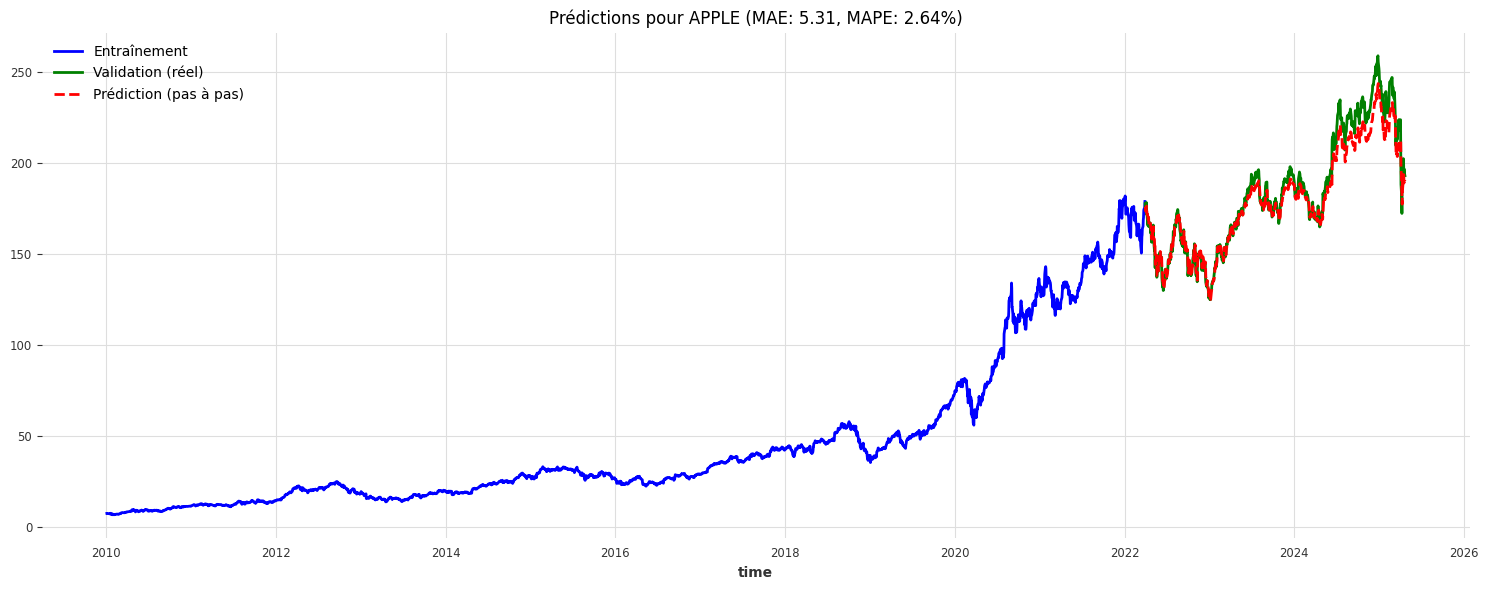

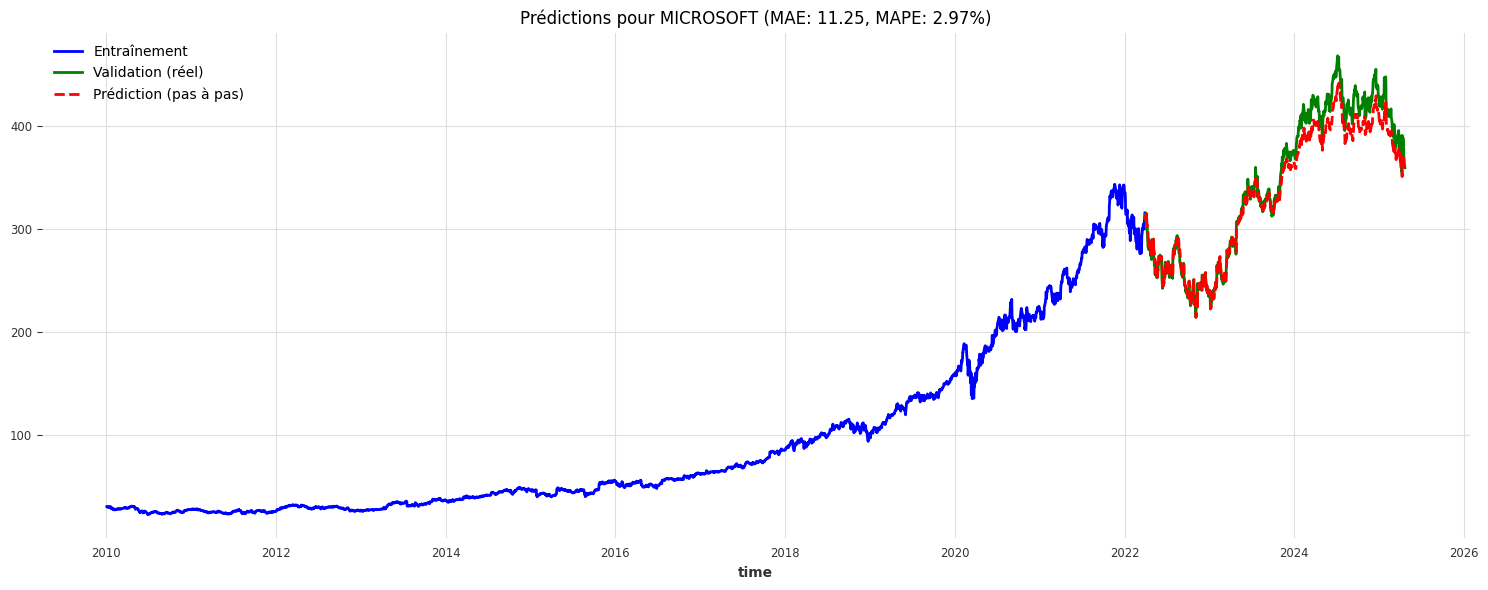

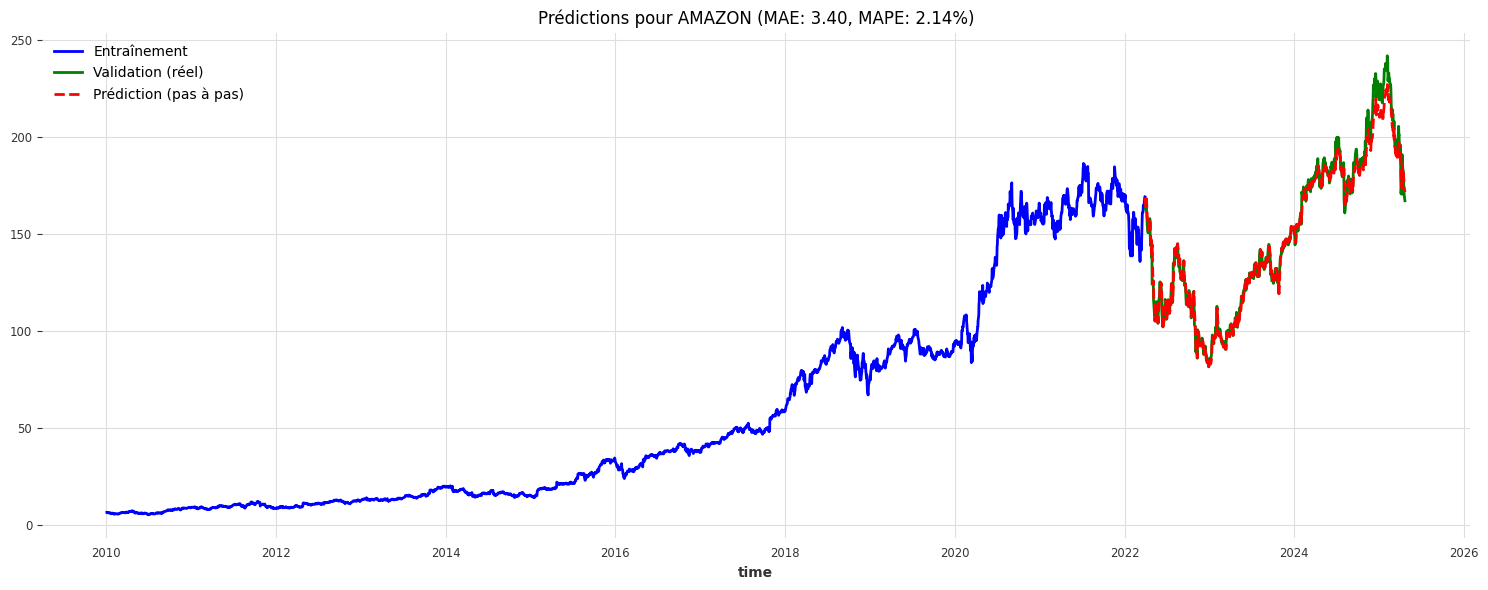

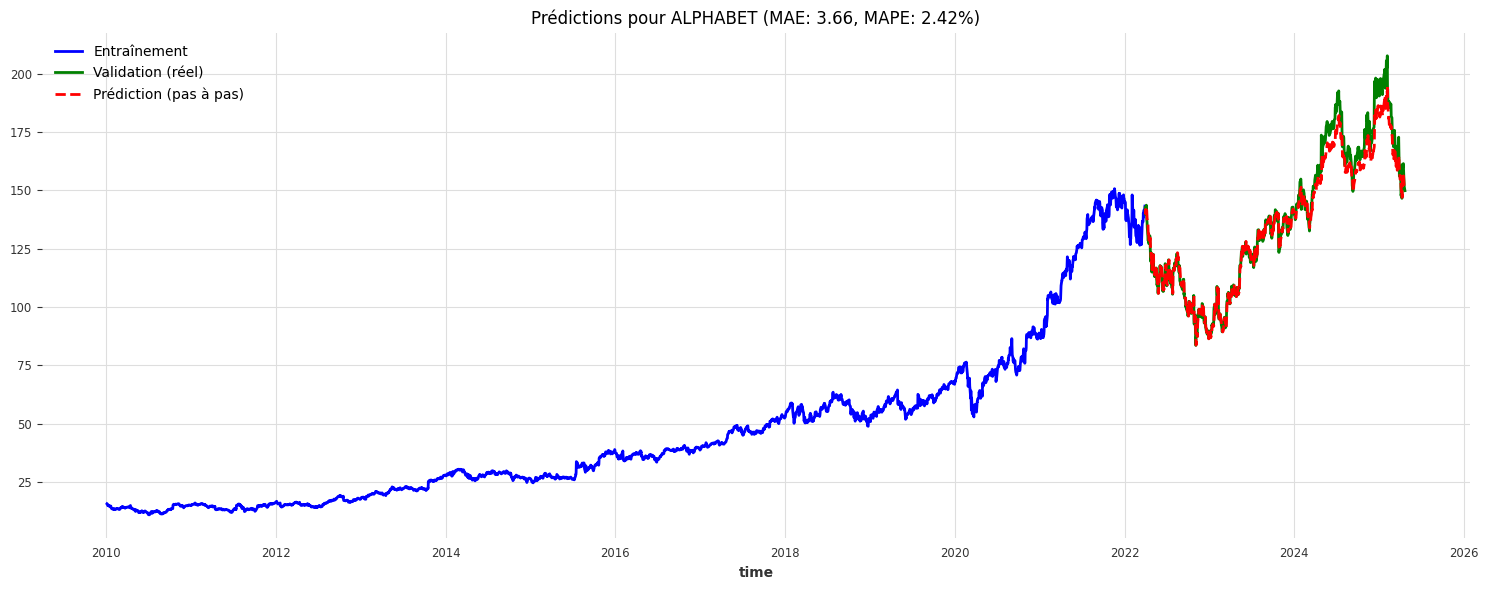

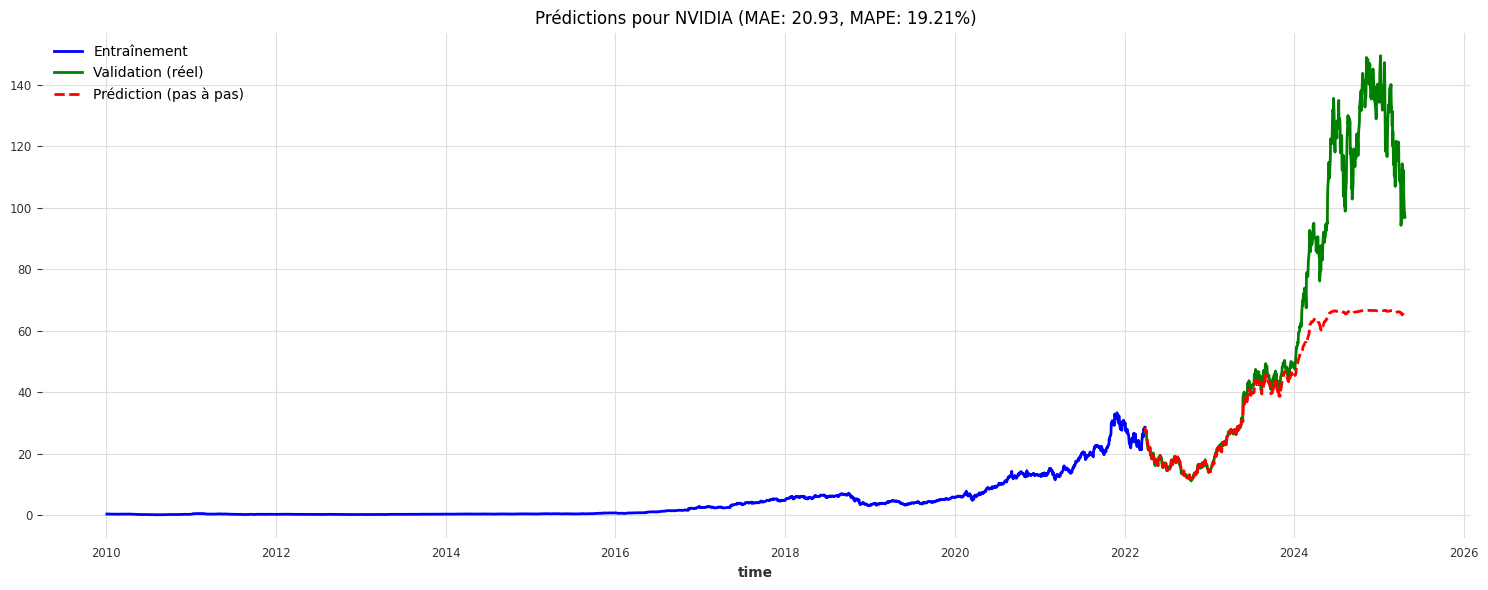

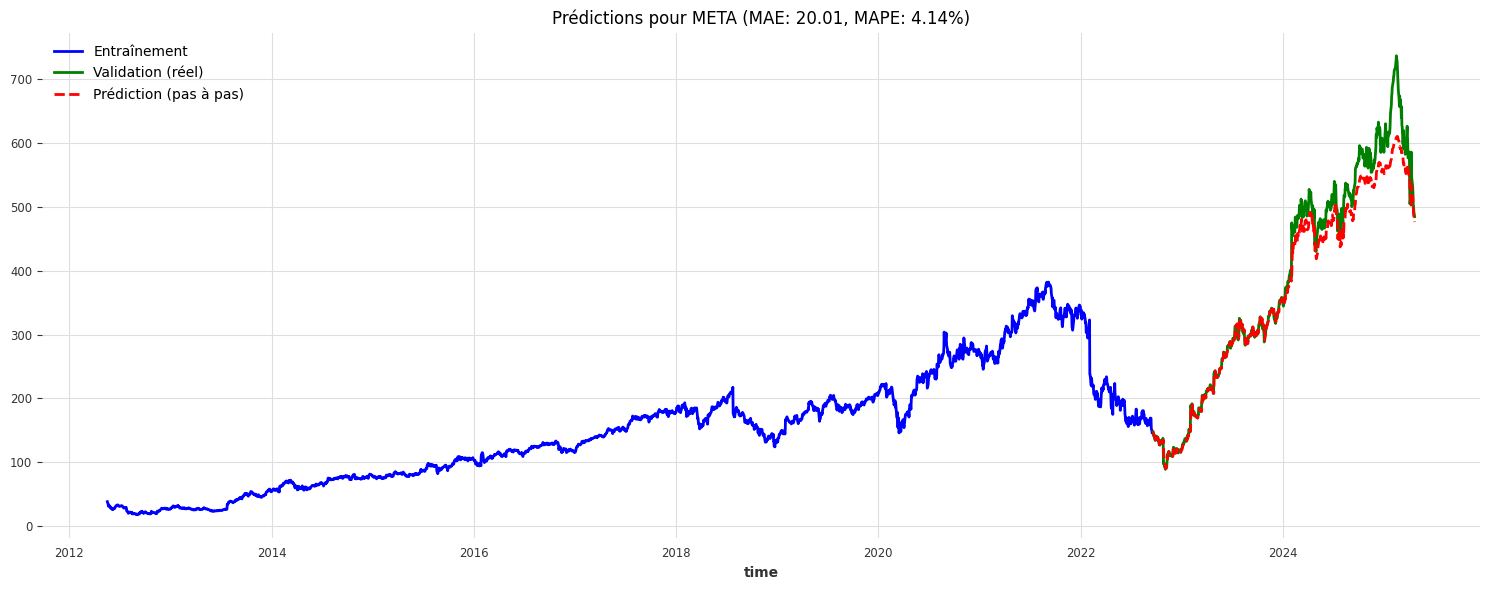

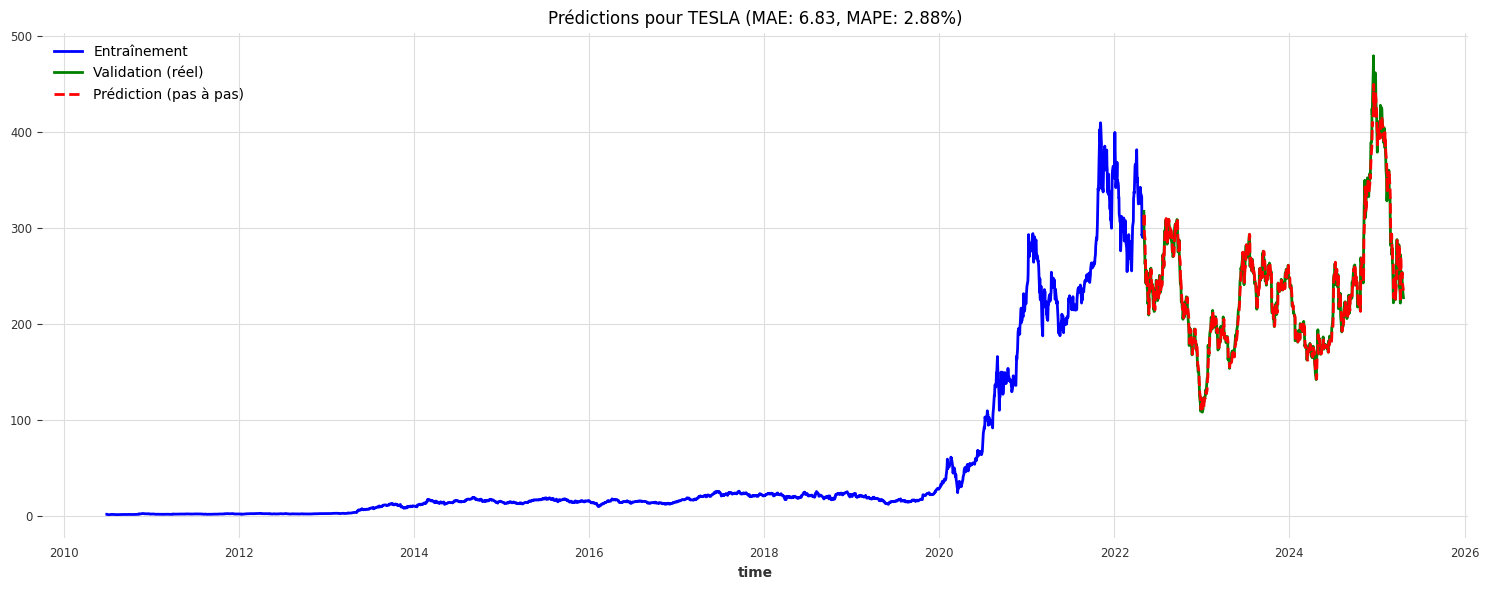

In [26]:
# Noms des entreprises pour les titres
company_names = ['APPLE', 'MICROSOFT', 'AMAZON', 'ALPHABET', 'NVIDIA', 'META', 'TESLA']

# Pour chaque série (entreprise)
for idx in range(len(train_series)):
    # Récupérer les données d'entraînement et de validation
    train_data = train_series[idx]
    val_data = val_series[idx]
    
    pred_data = all_predictions_for_plot[idx]

    mae_val = perf_df_walk_forward.loc[f'Série {idx}', 'MAE']
    mape_val = perf_df_walk_forward.loc[f'Série {idx}', 'MAPE']

    # Créer une nouvelle figure pour chaque entreprise
    plt.figure(figsize=(15, 6))

    # Tracer les séries temporelles
    train_data.plot(label='Entraînement', color='blue')
    val_data.plot(label='Validation (réel)', color='green')
    pred_data.plot(label='Prédiction (pas à pas)', color='red', linestyle='--')

    # Ajouter titre et légende avec métriques
    plt.title(f'Prédictions pour {company_names[idx]} (MAE: {mae_val:.2f}, MAPE: {mape_val:.2f}%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Analyse par entreprise:<br> 

Série	    MAE	        RMSE	       MAPE
Série 0	5.306578	7.180398	2.637468<br> 
Série 1	11.245208	14.409602	2.970643<br> 
Série 2	3.397900	4.910538	2.144158<br> 
Série 3	3.655795	5.077511	2.423542<br> 
Série 4	20.930553	34.015291	19.209708<br> 
Série 5	20.005825	30.732898	4.136618<br> 
Série 6	6.828841	9.722363	2.881486<br> 
<br> 
- APPLE (Série 0): Le modèle montre une très bonne performance avec un MAPE de 2.64%. Cela indique que les prédictions sont en moyenne très proches des valeurs réelles en termes de pourcentage. Le MAE (5.31) et RMSE (7.18) sont également faibles, signifiant une bonne précision absolue.<br> 
- MICROSOFT (Série 1): De très bonnes prédictions avec un MAPE de 2.97%. La précision est élevée, et les erreurs absolues (MAE de 11.25, RMSE de 14.41) sont bien maîtrisées, suggérant des prévisions fiables.<br> 
- AMAZON (Série 2): Le modèle performe excellemment avec le plus faible MAPE de 2.14%. C'est un signe d'une très haute précision relative. Les erreurs absolues (MAE de 3.40, RMSE de 4.91) sont également très basses.<br> 
- ALPHABET (Série 3): Des performances solides avec un MAPE de 2.42%. Les prédictions sont très précises, et les erreurs absolues (MAE de 3.66, RMSE de 5.08) sont comparables à celles d'Amazon, indiquant une grande fiabilité.<br> 
- NVIDIA (Série 4): C'est la série la plus difficile à prédire avec un MAPE de 19.21%. Bien que ce soit beaucoup plus élevé que les autres, cela reste un MAPE acceptable pour des séries très volatiles, mais les prédictions sont moins fiables en proportion. Les erreurs absolues (MAE de 20.93, RMSE de 34.02) sont également les plus élevées, ce qui n'est pas surprenant étant donné la nature de cette action.<br> 
- META (Série 5): Les prédictions sont très bonnes avec un MAPE de 4.14%. Malgré des erreurs absolues un peu plus élevées (MAE de 20.01, RMSE de 30.73), le faible MAPE indique que le modèle suit bien les mouvements relatifs du prix.<br> 
- TESLA (Série 6): Le modèle obtient un bon MAPE de 2.88%. Les erreurs absolues (MAE de 6.83, RMSE de 9.72) sont faibles, ce qui est prometteur pour la prédiction de cette action souvent volatile.<br> 
<br> 
Conclusions Principales<br> 
Les métriques obtenues après l'implémentation de l'évaluation "walk-forward" sont globalement excellentes, en particulier les MAPE qui sont majoritairement inférieurs à 5%, ce qui est un signe de très haute précision pour la prédiction de séries temporelles financières.<br> 
Très Haute Précision Générale: Pour la plupart des entreprises (Apple, Microsoft, Amazon, Alphabet, Meta, Tesla), le modèle démontre une capacité impressionnante à prédire le prochain point avec une grande précision relative, avec des MAPE souvent sous les 5%. C'est un résultat très encourageant.

Le modèle RNN démontre une capacité de prédiction extraordinairement élevée pour la majorité de vos séries, avec des MAPE très bas (souvent inférieurs à 3%), ce qui est phénoménal pour des données financières. Pour ces séries, le RNN est clairement le meilleur modèle que vous ayez testé jusqu'à présent, surpassant largement le TiDE et le TFT.<br>
<br>
Cependant, la faiblesse notable du RNN réside dans sa performance pour la Série 4 (NVIDIA). Ici, le MAPE de 19.21% est un point d'attention majeur, car il est significativement plus élevé et dégrade la performance globale du modèle pour cette série.